# chess-gnn: supervised training

Train the GNN on Lichess PGN data. Runs locally or on Colab (CPU / GPU / MPS).

The supervised objective trains both the policy head and the value head: each PGN position gets the played move as the policy target and the final game result, signed from the side-to-move's perspective, as the value target. This matters for MCTS, because search uses the value head to evaluate newly expanded leaves.

This notebook uses a two-stage schedule: first learn a stronger imitation policy with moderate value supervision, then resume from that checkpoint with a higher value weight and lower learning rate. A fixed validation probe tracks policy accuracy and value MSE on the same held-out positions after each stage.

- Local: launch from the repo root so the `chess_gnn` package is importable.
- Colab: the first cell clones/uploads the repo, installs deps, and downloads a small sample PGN.


In [1]:
# --- environment setup ---------------------------------------------------
import sys, os, subprocess, importlib, pathlib

IN_COLAB = "google.colab" in sys.modules
print("colab:", IN_COLAB)

REPO_URL = "https://github.com/jordanshivers/chess-gnn"  # optional: set to your GitHub URL to auto-clone on Colab
REPO_DIR = pathlib.Path("/content/chess") if IN_COLAB else pathlib.Path.cwd().parent

if IN_COLAB:
    if REPO_URL and not REPO_DIR.exists():
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    elif not REPO_DIR.exists():
        # Fallback: upload a zip of the repo via files.upload() and unzip
        from google.colab import files  # type: ignore
        print("No REPO_URL set — upload a zip of the repo (containing src/chess_gnn).")
        up = files.upload()
        name = next(iter(up))
        REPO_DIR.mkdir(parents=True, exist_ok=True)
        subprocess.check_call(["unzip", "-q", name, "-d", str(REPO_DIR)])

    subprocess.check_call([
        "pip", "install", "-q",
        "torch", "torch-geometric", "python-chess", "zstandard", "tqdm",
    ])
    subprocess.check_call(["pip", "install", "-q", "-e", str(REPO_DIR)])

# Make the package importable when running locally from notebooks/
src_path = str((REPO_DIR / "src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import torch
print("torch:", torch.__version__)
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("device:", DEVICE)

colab: True
torch: 2.10.0+cu128
device: cuda


In [4]:
# from google.colab import drive
# drive.mount("/content/drive")
# !cp -r /content/drive/MyDrive/chess-gnn-checkpoints/checkpoints /content/chess

# !ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
chess  drive  sample_data


In [2]:
# --- data: download Lichess PGNs -----------------------------------------
# Lichess publishes monthly PGN dumps and an 'Elite' subset. The Elite dumps
# are multi-GB; for a first run, pick a smaller recent monthly or use your own.
# Swap URLs as desired: https://database.lichess.org/

DATA_DIR = REPO_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
PGN_URL = "https://database.lichess.org/standard/lichess_db_standard_rated_2019-01.pgn.zst"
HELDOUT_PGN_URL = "https://database.lichess.org/standard/lichess_db_standard_rated_2013-01.pgn.zst"
PGN_PATH = DATA_DIR / pathlib.Path(PGN_URL).name
HELDOUT_PGN_PATH = DATA_DIR / pathlib.Path(HELDOUT_PGN_URL).name

for url, path in ((PGN_URL, PGN_PATH), (HELDOUT_PGN_URL, HELDOUT_PGN_PATH)):
    if not path.exists():
        subprocess.check_call(["curl", "-L", "--progress-bar", "-o", str(path), url])
    print("pgn:", path, f"{path.stat().st_size / 1e6:.1f} MB")

pgn: /content/chess/data/lichess_db_standard_rated_2019-01.pgn.zst 10078.5 MB
pgn: /content/chess/data/lichess_db_standard_rated_2013-01.pgn.zst 17.8 MB


In [3]:
# --- quick sanity: iterate a few samples ---------------------------------
from chess_gnn.dataset import PGNMoveDataset

MIN_ELO = 1800

ds = PGNMoveDataset([PGN_PATH], shuffle_buffer=256, min_elo=MIN_ELO)
it = iter(ds)
sample = next(it)
print("node feat:", sample.x.shape, "edges:", sample.edge_index.shape)
print("target move idx:", int(sample.y), "legal moves:", int(sample.legal_mask.sum()))
print("value target:", float(sample.value_target), "(side-to-move POV)")

node feat: torch.Size([64, 45]) edges: torch.Size([2, 4032])
target move idx: 3956 legal moves: 35
value target: 1.0 (side-to-move POV)


In [4]:
# --- fixed held-out validation probe -------------------------------------
from itertools import islice

import torch.nn.functional as F
from torch_geometric.data import Batch

from chess_gnn.model import load_model, masked_log_softmax
from chess_gnn.train_sl import topk_accuracy

HELDOUT_SIZE = 256
HELDOUT_SKIP = 25_000
HELDOUT_EVAL_BATCH_SIZE = 64

heldout_ds = PGNMoveDataset([HELDOUT_PGN_PATH], shuffle_buffer=1, min_elo=MIN_ELO)
heldout_samples = list(islice(iter(heldout_ds), HELDOUT_SKIP, HELDOUT_SKIP + HELDOUT_SIZE))
print("heldout positions:", len(heldout_samples), "from", HELDOUT_PGN_PATH)


def evaluate_sl_checkpoint(samples, ckpt_path, device=DEVICE, batch_size=HELDOUT_EVAL_BATCH_SIZE):
    model = load_model(ckpt_path, device=device)
    model.eval()
    totals = {"n": 0, "policy": 0.0, "value": 0.0, "top1": 0.0, "top5": 0.0, "value_sum": 0.0, "target_sum": 0.0}
    with torch.no_grad():
        for start in range(0, len(samples), batch_size):
            batch = Batch.from_data_list(samples[start : start + batch_size]).to(device)
            policy, _, value = model(batch)
            mask = batch.legal_mask.view(-1, policy.size(-1))
            log_probs = masked_log_softmax(policy, mask)
            value_target = batch.value_target.view_as(value).to(dtype=value.dtype)
            n = batch.y.size(0)
            totals["n"] += n
            totals["policy"] += F.nll_loss(log_probs, batch.y, reduction="sum").item()
            totals["value"] += F.mse_loss(value, value_target, reduction="sum").item()
            totals["top1"] += topk_accuracy(log_probs, batch.y, 1) * n
            totals["top5"] += topk_accuracy(log_probs, batch.y, 5) * n
            totals["value_sum"] += float(value.sum().item())
            totals["target_sum"] += float(value_target.sum().item())
    n = max(totals["n"], 1)
    print(
        f"eval {pathlib.Path(ckpt_path).name}: "
        f"policy {totals['policy']/n:.4f} | v {totals['value']/n:.4f} | "
        f"top1 {totals['top1']/n:.3f} | top5 {totals['top5']/n:.3f} | "
        f"value_mean {totals['value_sum']/n:+.3f} target_mean {totals['target_sum']/n:+.3f}"
    )

heldout positions: 256 from /content/chess/data/lichess_db_standard_rated_2013-01.pgn.zst


In [5]:
# --- two-stage train -----------------------------------------------------
from chess_gnn.train_sl import train

CKPT_DIR = REPO_DIR / "checkpoints" / "sl"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Tune these for your hardware. On Colab T4, start with bs=128 for 128 hidden / 4 layers.
# Stage 1 learns the imitation policy with moderate value supervision.
# Stage 2 resumes from stage 1 and emphasizes the value head with a lower LR.
STAGE1_STEPS = 50_000
STAGE2_STEPS = 25_000
BATCH_SIZE = 128
NUM_WORKERS = 12

train(
    pgn_paths=[PGN_PATH],
    ckpt_dir=CKPT_DIR,
    steps=STAGE1_STEPS,
    batch_size=BATCH_SIZE,
    lr=3e-4,
    hidden_dim=128,
    num_layers=4,
    num_heads=4,
    min_elo=MIN_ELO,
    num_workers=NUM_WORKERS,
    log_every=100,
    ckpt_every=2500,
    device=DEVICE,
    value_coef=0.25,
)
evaluate_sl_checkpoint(heldout_samples, CKPT_DIR / "sl_final.pt")

stage1_ckpt = CKPT_DIR / "sl_final.pt"
train(
    pgn_paths=[PGN_PATH],
    ckpt_dir=CKPT_DIR,
    steps=STAGE1_STEPS + STAGE2_STEPS,  # train() treats steps as total global steps when resuming
    batch_size=BATCH_SIZE,
    lr=1e-4,
    hidden_dim=128,
    num_layers=4,
    num_heads=4,
    min_elo=MIN_ELO,
    num_workers=NUM_WORKERS,
    log_every=100,
    ckpt_every=2500,
    device=DEVICE,
    resume=stage1_ckpt,
    value_coef=0.75,
)
evaluate_sl_checkpoint(heldout_samples, CKPT_DIR / "sl_final.pt")

step     100 | loss 3.1498 | v 0.9189 | top1 0.198 | top5 0.487 | 781.2 pos/s
step     200 | loss 2.9871 | v 0.9391 | top1 0.242 | top5 0.543 | 964.6 pos/s
step     300 | loss 2.9388 | v 0.9478 | top1 0.255 | top5 0.560 | 954.9 pos/s
step     400 | loss 2.9262 | v 0.9437 | top1 0.262 | top5 0.564 | 919.0 pos/s
step     500 | loss 2.9175 | v 0.9289 | top1 0.258 | top5 0.561 | 941.9 pos/s
step     600 | loss 2.8959 | v 0.9498 | top1 0.267 | top5 0.568 | 954.0 pos/s
step     700 | loss 2.8530 | v 0.9453 | top1 0.277 | top5 0.582 | 956.8 pos/s
step     800 | loss 2.8654 | v 0.9518 | top1 0.277 | top5 0.578 | 940.6 pos/s
step     900 | loss 2.8566 | v 0.9645 | top1 0.272 | top5 0.583 | 967.5 pos/s
step    1000 | loss 2.7971 | v 0.9126 | top1 0.282 | top5 0.596 | 937.5 pos/s
step    1100 | loss 2.7806 | v 0.9330 | top1 0.288 | top5 0.598 | 954.9 pos/s
step    1200 | loss 2.7589 | v 0.9216 | top1 0.292 | top5 0.611 | 1010.2 pos/s
step    1300 | loss 2.7455 | v 0.9484 | top1 0.294 | top5 0.620

loading /content/chess/checkpoints/sl/sl_final.pt
arch: {'hidden_dim': 128, 'num_layers': 4, 'num_heads': 4, 'dropout': 0.0}
   b8c6  0.760
   g8f6  0.110
   d7d6  0.080
   d7d5  0.025
   f7f5  0.010
   f8c5  0.005
   c7c6  0.005
   c7c5  0.005


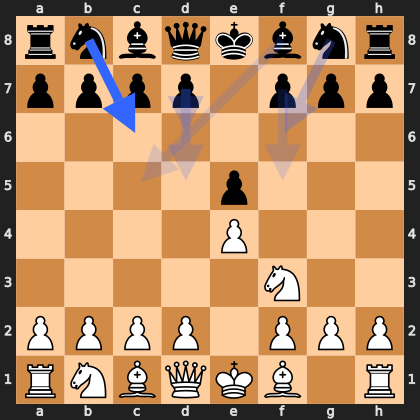

In [6]:
# --- load checkpoint and inspect predictions ------------------------------
import chess
from IPython.display import SVG, display

from chess_gnn.model import load_model
from chess_gnn.play import GNNAgent
from chess_gnn.viz import render_prediction_svg

ckpt = CKPT_DIR / "sl_final.pt"
print("loading", ckpt)
model = load_model(ckpt, device=DEVICE)  # reads arch config from the checkpoint
print("arch:", model.config)
# num_simulations=200 enables PUCT MCTS; set to 0 for raw policy (much faster).
# MCTS is useful only once held-out value MSE is clearly improving.
agent = GNNAgent(model, device=DEVICE, default_temperature=0.3, num_simulations=200)

board = chess.Board()
board.push_san("e4"); board.push_san("e5"); board.push_san("Nf3")
ranking = agent.rank_moves(board)
for m, p in list(zip(ranking.moves, ranking.probabilities))[:8]:
    print(f"  {m.uci():>5s}  {p:.3f}")
display(SVG(render_prediction_svg(board, ranking, topk=6)))

result: * plies: 8


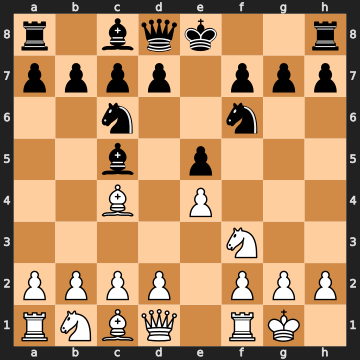

In [7]:
# --- optional: play a short self-play game at low temperature ------------
from chess_gnn.play import play_game

final_board, result = play_game(agent, agent, temperature=0.2, max_plies=8)
print("result:", result, "plies:", final_board.ply())
display(SVG(chess.svg.board(final_board, size=360)))

In [9]:
# from google.colab import drive
# drive.mount("/content/drive")
# !cp -r /content/chess/checkpoints /content/drive/MyDrive/chess-gnn-checkpoints



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
